In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('Project_description_and_data/claims_train.csv')

df['HighClaimRisk'] = (df['ClaimNb'] > 1).astype(int)


Notes on the ideas behind this model:
- PCA suggests virtually no separability between 0 and 1 claims, but visually clear distinction between 2 or more
    - Reframing as a binary classification problem will simplify the target and potentially improve prediction
    - Put in a real world, 1 claim can happen by accident, the person is not the responsible one but as the claim number grows, the likelihood of not being the reponsible decreases
    - 

In [7]:
df['VehAge_1']=df['VehAge'] +1
df['VehAge_log']=np.log(df['VehAge_1'])

df['DrivAge_log']=np.log(df['DrivAge'])
df['Density_log']=np.log(df['Density'])

low_cn=df[df['ClaimNb']>=1]

C:\Users\anna-\AppData\Local\Temp\ipykernel_11228\4212272572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn['VehGas']=np.where((low_cn['VehGas']=='Regular'), 0, 1)
C:\Users\anna-\AppData\Local\Temp\ipykernel_11228\4212272572.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn["PC1"] = X_pca[:, 0]
C:\Users\anna-\AppData\Local\Temp\ipykernel_11228\4212272572.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

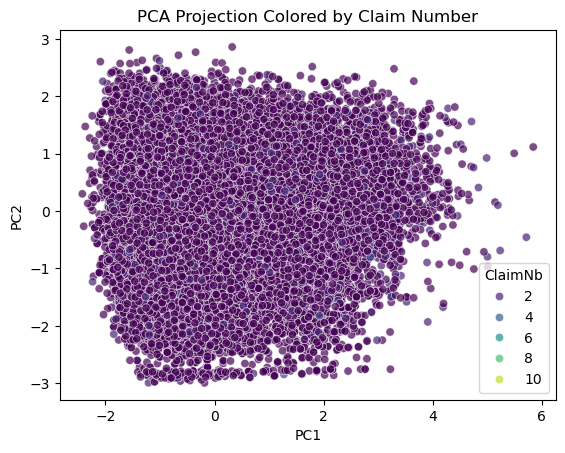

PC1: 32.05%, PC2: 22.17%, Total: 54.23%
                  PC1       PC2
DrivAge_log -0.669991  0.001591
VehPower    -0.077376 -0.033904
VehAge_log   0.169727  0.715662
Density_log  0.196959 -0.697314
BonusMalus   0.691032  0.020720


In [9]:
low_cn['VehGas']=np.where((low_cn['VehGas']=='Regular'), 0, 1)

features = ['DrivAge_log', 'VehPower', 'VehAge_log', 'Density_log', 'BonusMalus']            # tried adding VehBrand too but it destroyed the PCA :D

from sklearn.preprocessing import StandardScaler

X = low_cn[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)   # for 2D visualization
X_pca = pca.fit_transform(X_scaled)

low_cn["PC1"] = X_pca[:, 0]
low_cn["PC2"] = X_pca[:, 1]

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="ClaimNb",
    data=low_cn,
    palette="viridis",
    alpha=0.7
)

#plt.ylim(-3, 5)
plt.title("PCA Projection Colored by Claim Number")
plt.show()

explained = pca.explained_variance_ratio_
print(f"PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}, Total: {explained[:2].sum():.2%}")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)
print(loadings)

# Adding PC1 and PC2 as features:

- Though PCA was only done for datapoints with 2 or more claims, this following method fills the PC1 and PC2 columns in rows with 0 or 1 claims with the mean of the respected column.
- These PCs are domain-informed latent features, only meaningful for higher-claim subspace, but potentially beneficial in boundary modeling.

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt


df=pd.read_csv('Project_description_and_data/claims_train.csv')
df['target'] = np.where(df['ClaimNb'] >= 1, 1, 0)

df['VehAge_1']    = df['VehAge'] + 1
df['VehAge_log']  = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])
#df['VehGas'] = np.where((df['VehGas']=='Regular'), 0, 1)

df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)

# -----------------------------
# 3. PCA creation using all data (avoids leakage)
# -----------------------------
pca_features = ['DrivAge_log','VehPower','VehAge_log',
                'Density_log','BonusMalus']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]


cat_cols = ['VehBrand','Area', 'Region', 'VehGas']
for c in cat_cols:
    df[c] = df[c].astype('category')

df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
df['VehPower_DensityLog'] = df['VehPower'] * df['Density_log']
df['VehAgeLog_Brand'] = df['VehAge_log'] * df['VehBrand'].cat.codes
# df['Region_DensityLog'] = df['Region'].cat.codes * df['Density_log']
df['BonusMalus_Exposure'] = df['BonusMalus'] * df['Exposure_adj']
df['VehPower_VehGas'] = df['VehPower'] * df['VehGas'].cat.codes
df['PC1_BonusMalus'] = df['PC1'] * df['BonusMalus']
df['PC2_DrivAgeLog'] = df['PC2'] * df['DrivAge_log']

interaction_features = [
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'VehAgeLog_Brand',
    'BonusMalus_Exposure',
    'VehPower_VehGas'
]


features = ['Exposure_adj', 'VehPower', 'DrivAge_log', 'BonusMalus',
            'Density_log', 'VehBrand', 'VehAge_log', 'Region'] + interaction_features

X = df[features]
y = df['target']
weights = df['Exposure_adj']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in sss.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]



pos= df['target'].sum()
neg= len(df)-pos
scale=neg/pos

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    max_depth=6,
    learning_rate=0.01,
    n_estimators=500,
    subsample=0.7,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    enable_categorical=True
)


param_grid = {
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [300, 500, 700],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}


grid_search = GridSearchCV(                 # Set up GridSearchCV with stratified 5-fold cross-validation
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)           #fit grid search

best_model = grid_search.best_estimator_    #save the best model

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated ROC-AUC:", grid_search.best_score_)

y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:, 1]

roc = roc_auc_score(y_val, y_prob)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print(f"ROC-AUC: {roc:.3f}")
print(f"F1-Score: {f1:.3f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, digits=3))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:20:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "classifier__colsample_bytree", "classifier__learning_rate", "classifier__max_depth", "classifier__n_estimators", "classifier__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.7}
Best cross-validated ROC-AUC: 0.6990509612263303
ROC-AUC: 0.707
F1-Score: 0.154
Confusion Matrix:
[[66750 36290]
 [ 1963  3479]]

Classification Report:
              precision    recall  f1-score   support

           0      0.971     0.648     0.777    103040
           1      0.087     0.639     0.154      5442

    accuracy                          0.647    108482
   macro avg      0.529     0.644     0.466    108482
weighted avg      0.927     0.647     0.746    108482



In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

if {'PC1', 'PC2'}.issubset(df.columns):
    features_to_use = [
        'Exposure', 'VehPower', 'DrivAge_log', 'BonusMalus', 'Density_log',
        'VehBrand', 'VehAge_log', 'VehGas', 'Area', 'Region', 'PC1', 'PC2'
    ]
else:
    features_to_use = [
        'Exposure', 'VehPower', 'DrivAge_log', 'BonusMalus', 'Density_log',
        'VehBrand', 'VehAge_log', 'VehGas', 'Area', 'Region'
    ]

X = df[features_to_use]
y = df['HighClaimRisk']


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in sss.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)


best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.01,
    'max_depth': 4,
    'n_estimators': 500,
    'subsample': 0.7
}

xgb = XGBClassifier(
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for fold, (train_idx, test_idx) in enumerate(kf.split(X_train, y_train), 1):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model.fit(X_tr, y_tr)
    preds = model.predict_proba(X_te)[:, 1]
    score = roc_auc_score(y_te, preds)
    cv_scores.append(score)
    print(f"Fold {fold} ROC-AUC: {score:.3f}")

print(f"\nMean CV ROC-AUC: {np.mean(cv_scores):.3f}")

# -------------------------
# Final training on full training split
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# Validation results
# -------------------------
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

roc = roc_auc_score(y_val, y_prob)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print(f"\nValidation ROC-AUC: {roc:.3f}")
print(f"Validation F1-Score: {f1:.3f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, digits=3))


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:53:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 ROC-AUC: 0.751


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:53:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 ROC-AUC: 0.701


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:53:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

Fold 4 ROC-AUC: 0.714


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:54:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 ROC-AUC: 0.716

Mean CV ROC-AUC: 0.722


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:54:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Validation ROC-AUC: 0.710
Validation F1-Score: 0.012
Confusion Matrix:
[[80622 27561]
 [  137   162]]

Classification Report:
              precision    recall  f1-score   support

           0      0.998     0.745     0.853    108183
           1      0.006     0.542     0.012       299

    accuracy                          0.745    108482
   macro avg      0.502     0.644     0.432    108482
weighted avg      0.996     0.745     0.851    108482



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

df=pd.read_csv('Project_description_and_data/claims_train.csv')
df['target'] = np.where(df['ClaimNb'] >= 1, 1, 0)

df['VehAge_1']    = df['VehAge'] + 1
df['VehAge_log']  = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])
#df['VehGas'] = np.where((df['VehGas']=='Regular'), 0, 1)

df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)

# -----------------------------
# 3. PCA creation using all data (avoids leakage)
# -----------------------------
pca_features = [
    'DrivAge_log',
    'VehPower',
    'VehAge_log',
    'Density_log',
    'BonusMalus'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['PC3'] = X_pca[:, 2]
df['PC4'] = X_pca[:, 3]

cat_cols = ['VehBrand','Area', 'Region', 'VehGas']
for c in cat_cols:
    df[c] = df[c].astype('category')

df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
df['VehPower_DensityLog'] = df['VehPower'] * df['Density_log']
df['VehAgeLog_Brand'] = df['VehAge_log'] * df['VehBrand'].cat.codes
# df['Region_DensityLog'] = df['Region'].cat.codes * df['Density_log']
df['BonusMalus_Exposure'] = df['BonusMalus'] * df['Exposure_adj']
df['VehPower_VehGas'] = df['VehPower'] * df['VehGas'].cat.codes
df['PC1_BonusMalus'] = df['PC1'] * df['BonusMalus']
df['PC2_DrivAgeLog'] = df['PC2'] * df['DrivAge_log']

interaction_features = [
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'VehAgeLog_Brand',
    'BonusMalus_Exposure',
    'VehPower_VehGas'
]


features = ['VehBrand', 'Region', 'PC1', 'PC2', 'PC3', 'PC4'] + interaction_features

X = df[features]
y = df['target']
weights = df['Exposure_adj']


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# XGBoost classifier - best parameters found by GridSearchCV: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.7}
# -----------------------------

pos= df['target'].sum()
neg= len(df)-pos
scale=neg/pos

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    max_depth=6,
    learning_rate=0.01,
    n_estimators=500,
    subsample=0.7,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    enable_categorical=True
)

model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)


pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, proba))
print('PR-AUC:', average_precision_score(y_test, proba))
print(classification_report(y_test, pred))


AUC: 0.7014535919513172
PR-AUC: 0.13332247883857343
              precision    recall  f1-score   support

           0       0.97      0.64      0.77    103040
           1       0.09      0.64      0.15      5442

    accuracy                           0.64    108482
   macro avg       0.53      0.64      0.46    108482
weighted avg       0.93      0.64      0.74    108482



Observations: 
- When PC1 and PC2 removed from the model the PR-AUC imporved from 0.008 to 0.01
- after adding interaction features: 0.012


In [5]:
proba = model.predict_proba(X_test)[:, 1]

for t in [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]:
    pred_t = (proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, pred_t, digits=3))


Threshold: 0.5
              precision    recall  f1-score   support

           0      0.971     0.641     0.772    103040
           1      0.086     0.643     0.152      5442

    accuracy                          0.641    108482
   macro avg      0.529     0.642     0.462    108482
weighted avg      0.927     0.641     0.741    108482


Threshold: 0.4
              precision    recall  f1-score   support

           0      0.979     0.379     0.546    103040
           1      0.067     0.849     0.125      5442

    accuracy                          0.402    108482
   macro avg      0.523     0.614     0.335    108482
weighted avg      0.934     0.402     0.525    108482


Threshold: 0.3
              precision    recall  f1-score   support

           0      0.986     0.178     0.302    103040
           1      0.058     0.952     0.109      5442

    accuracy                          0.217    108482
   macro avg      0.522     0.565     0.205    108482
weighted avg      0.939   

c:\Users\aply\OneDrive - Demant\Desktop\Local files\Local files\DIXA project\ml_project\csat_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aply\OneDrive - Demant\Desktop\Local files\Local files\DIXA project\ml_project\csat_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aply\OneDrive - Demant\Desktop\Local files\Local files\DIXA project\ml_project\csat_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill

<Figure size 1000x1200 with 0 Axes>

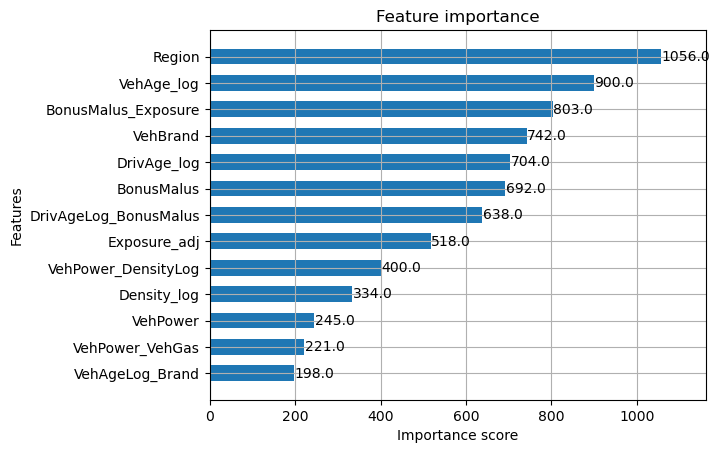

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Built-in importance plot
plt.figure(figsize=(10, 12))
plot_importance(model, max_num_features=30, height=0.6)
plt.show()

In [7]:
importance_dict = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values('Importance', ascending=False)

print(importance_df)

                  Feature  Importance
11    BonusMalus_Exposure  686.123352
8   DrivAgeLog_BonusMalus  317.225769
6              VehAge_log  269.842072
3              BonusMalus  243.291519
2             DrivAge_log  183.108536
12        VehPower_VehGas  153.276077
5                VehBrand  146.964310
0            Exposure_adj  140.724701
1                VehPower  113.788231
7                  Region  113.737541
10        VehAgeLog_Brand  103.955719
4             Density_log   91.228592
9     VehPower_DensityLog   86.623573


In [60]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    scoring='average_precision',  # better for imbalanced data
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_df.head(30))

                  feature  importance_mean  importance_std
10  DrivAgeLog_BonusMalus         0.007166        0.000688
14    BonusMalus_Exposure         0.006773        0.000435
3              BonusMalus         0.004224        0.000897
5                VehBrand         0.003299        0.001337
9                  Region         0.002821        0.000999
2             DrivAge_log         0.002803        0.000488
11    VehPower_DensityLog         0.002262        0.001638
0            Exposure_adj         0.002234        0.002121
15        VehPower_VehGas         0.001836        0.000470
6              VehAge_log         0.001696        0.001615
4             Density_log         0.001531        0.001318
12        VehAgeLog_Brand         0.001326        0.001334
1                VehPower         0.000381        0.001022
13      Region_DensityLog        -0.000040        0.001070
7                  VehGas        -0.000062        0.000104
8                    Area        -0.000171        0.0006

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from xgboost import XGBClassifier

df=pd.read_csv('Project_description_and_data/claims_train.csv')

df['target'] = np.where(df['ClaimNb'] >= 2, 1, 0)

df['VehAge_1'] = df['VehAge'] + 1
df['VehAge_log'] = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])

df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)               # transforms everything >1.0 into 1.0 to 

cat_cols = ['VehBrand', 'Area', 'Region', 'VehGas']
for c in cat_cols:
    df[c] = df[c].astype('category')

df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
df['VehPower_DensityLog'] = df['VehPower'] * df['Density_log']
df['VehAgeLog_Brand'] = df['VehAge_log'] * df['VehBrand'].cat.codes
df['BonusMalus_Exposure'] = df['BonusMalus'] * df['Exposure_adj']
df['VehPower_VehGas'] = df['VehPower'] * df['VehGas'].cat.codes

interaction_features = [
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'VehAgeLog_Brand',
    'BonusMalus_Exposure',
    'VehPower_VehGas',
]


features = [
    'Exposure_adj', 'VehPower', 'DrivAge_log', 'BonusMalus',
    'Density_log', 'VehBrand', 'VehAge_log', 'Region', 'VehGas', 'Area'
] + interaction_features

X = df[features]
y = df['target']
weights = df['Exposure_adj']


sss = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

for train_idx, val_idx in sss.split(X, y):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    w_train = weights.iloc[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]
    w_val = weights.iloc[val_idx]


pos = y_train.sum()
neg = len(y_train) - pos
scale = neg / pos


xgb = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc"
)


param_grid = {
    'max_depth': [3, 4, 5, 7, 9],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [300, 500, 800, 900],
    'subsample': [0.5, 0.7, 0.9],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale]     # keep fixed (data imbalance)
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='average_precision',    # PR-AUC better for imbalance
    n_jobs=-1,
    cv=5,
    verbose=1
)

grid.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_


proba = best_model.predict_proba(X_val)[:,1]
pred  = best_model.predict(X_val)

print("Val ROC-AUC :", roc_auc_score(y_val, proba))
print("Val PR-AUC  :", average_precision_score(y_val, proba))
print(classification_report(y_val, pred))


def evaluate_external_test(path_to_csv):
    test_df = pd.read_csv(path_to_csv)

    # --- identical preprocessing steps must be applied ---
    test_df['target'] = np.where(test_df['ClaimNb'] >= 2, 1, 0)

    test_df['VehAge_1']    = test_df['VehAge'] + 1
    test_df['VehAge_log']  = np.log(test_df['VehAge_1'])
    test_df['DrivAge_log'] = np.log(test_df['DrivAge'])
    test_df['Density_log'] = np.log(test_df['Density'])
    test_df['Exposure_adj'] = test_df['Exposure'].clip(upper=1.0)

    for c in cat_cols:
        test_df[c] = test_df[c].astype('category')

    test_df['DrivAgeLog_BonusMalus'] = test_df['DrivAge_log'] * test_df['BonusMalus']
    test_df['VehPower_DensityLog']   = test_df['VehPower'] * test_df['Density_log']
    test_df['VehAgeLog_Brand']       = test_df['VehAge_log'] * test_df['VehBrand'].cat.codes
    test_df['BonusMalus_Exposure']   = test_df['BonusMalus'] * test_df['Exposure_adj']
    test_df['VehPower_VehGas']       = test_df['VehPower'] * test_df['VehGas'].cat.codes

    X_test_ext = test_df[features]
    y_test_ext = test_df['target']
    w_test_ext = test_df['Exposure_adj']

    proba_ext = best_model.predict_proba(X_test_ext)[:,1]
    pred_ext = best_model.predict(X_test_ext)

    print("\n### External Test Set Results ###")
    print("ROC-AUC:", roc_auc_score(y_test_ext, proba_ext))
    print("PR-AUC:", average_precision_score(y_test_ext, proba_ext))
    print(classification_report(y_test_ext, pred_ext))


evaluate_external_test('Project_description_and_data/claims_test.csv')


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 900, 'scale_pos_weight': np.float64(362.42378559463987), 'subsample': 0.9}
Val ROC-AUC : 0.6970178766519026
Val PR-AUC  : 0.011613689316820776
              precision    recall  f1-score   support

           0       1.00      0.71      0.83    108183
           1       0.01      0.55      0.01       299

    accuracy                           0.71    108482
   macro avg       0.50      0.63      0.42    108482
weighted avg       1.00      0.71      0.83    108482


### External Test Set Results ###
ROC-AUC: 0.6971425434985037
PR-AUC: 0.011184433625659681
              precision    recall  f1-score   support

           0       1.00      0.71      0.83    135214
           1       0.01      0.58      0.01       389

    accuracy                           0.71    135603
   macro avg       0.50      0.64      0.42    135603
weig